# 01 - EDA & Khám phá dữ liệu: Pima Indians Diabetes Database

**Mục tiêu:**
- Load và xem tổng quan dataset
- Kiểm tra chất lượng dữ liệu (sạch hay bẩn?)
- Phân tích phân bố từng biến
- Phát hiện outlier
- Phân tích tương quan
- Chọn features và models

## Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")

## Section 1: Load dữ liệu
Chúng ta sẽ load dữ liệu từ file CSV và xem kích thước cũng như một vài mẫu dữ liệu.

In [2]:
DATA_PATH = "../data/raw/diabetes.csv"
df = pd.read_csv(DATA_PATH)
print(f"Kích thước dataset: {df.shape}")
display(df.head(10))

Kích thước dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
display(df.tail(5))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [4]:
display(df.sample(5, random_state=42))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
668,6,98,58,33,190,34.0,0.430,43,0
324,2,112,75,32,0,35.7,0.148,21,0
624,2,108,64,0,0,30.8,0.158,21,0
690,8,107,80,0,0,24.6,0.856,34,0
473,7,136,90,0,0,29.9,0.210,50,0


## Section 2: Tổng quan dữ liệu
Kiểm tra cấu trúc và chất lượng dữ liệu ban đầu.

In [5]:
print("Cột dữ liệu:", df.columns.tolist())
print("\nKiểu dữ liệu:")
print(df.dtypes)

Cột dữ liệu: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Kiểu dữ liệu:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


**Nhận xét:** Có thể thấy giá trị min của một số cột như Glucose, BloodPressure, SkinThickness, Insulin, BMI bằng 0. Đây là điều không hợp lý về mặt y khoa.

In [8]:
df.nunique()

Pregnancies                  17
Glucose                     136
BloodPressure                47
SkinThickness                51
Insulin                     186
BMI                         248
DiabetesPedigreeFunction    517
Age                          52
Outcome                       2
dtype: int64

In [9]:
print(f"Số lượng dòng trùng lặp: {df.duplicated().sum()}")

Số lượng dòng trùng lặp: 0


In [11]:
print("Số lượng giá trị null:")
print(df.isnull().sum())

Số lượng giá trị null:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


**Nhận xét ban đầu:** Dữ liệu không chứa giá trị NaN (null) thực sự, nhưng lại có rất nhiều giá trị 0 ở các cột y tế quan trọng (như Glucose, Huyết áp, v.v.). Điều này là bất khả thi trong thực tế lâm sàng, do đó các giá trị 0 này thực chất là *Missing Values* (dữ liệu bị thiếu). Kết luận: Dữ liệu BẨN.

## Section 3: Phát hiện Missing Values ẩn (giá trị 0 bất hợp lý)
Trong dữ liệu y khoa, đường huyết hay huyết áp bằng 0 là người đã chết. Chúng ta sẽ đếm xem có bao nhiêu giá trị 0.

In [12]:
cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in cols_with_zero:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} giá trị 0 ({zeros / len(df) * 100:.2f}%)")

Glucose: 5 giá trị 0 (0.65%)
BloodPressure: 35 giá trị 0 (4.56%)
SkinThickness: 227 giá trị 0 (29.56%)
Insulin: 374 giá trị 0 (48.70%)
BMI: 11 giá trị 0 (1.43%)


In [13]:
zero_counts = {col: (df[col] == 0).sum() for col in cols_with_zero}
zero_df = pd.DataFrame(list(zero_counts.items()), columns=["Cột", "Số lượng giá trị 0"])
zero_df["Tỷ lệ (%)"] = round(zero_df["Số lượng giá trị 0"] / len(df) * 100, 2)
display(zero_df)

,Cột,Số lượng giá trị 0,Tỷ lệ (%)
0,Glucose,5,0.65
1,BloodPressure,35,4.56
2,SkinThickness,227,29.56
3,Insulin,374,48.70
4,BMI,11,1.43


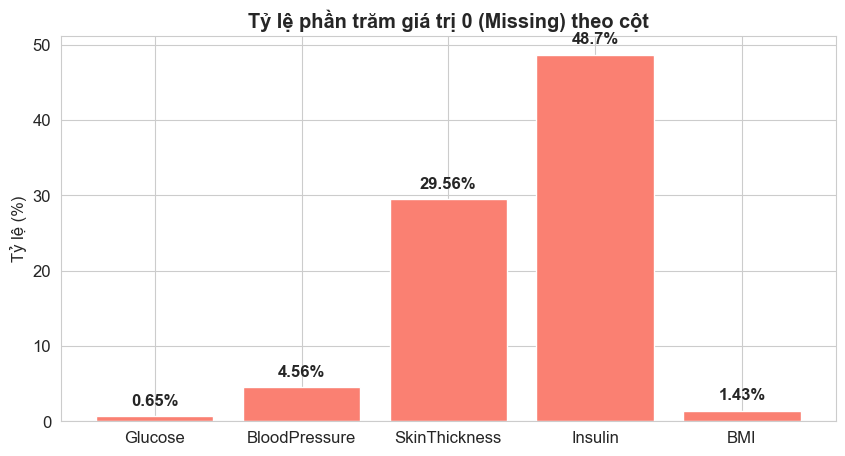

In [14]:
plt.figure(figsize=(10, 5))
bars = plt.bar(zero_df["Cột"], zero_df["Tỷ lệ (%)"], color="salmon")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}%", ha="center", va="bottom", fontweight="bold")
plt.title("Tỷ lệ phần trăm giá trị 0 (Missing) theo cột", fontweight="bold")
plt.ylabel("Tỷ lệ (%)")
plt.show()

**Kết luận:** Dữ liệu BẨN - đặc biệt cột Insulin thiếu tới 48.7%. Cần thực hiện tiền xử lý dữ liệu ở bước sau (thay thế bằng NaN và impute).

## Section 4: Phân bố biến mục tiêu (Outcome)
Biến `Outcome` nhận giá trị 1 (có tiểu đường) và 0 (không có).

In [15]:
print(df["Outcome"].value_counts())
print(df["Outcome"].value_counts(normalize=True) * 100)

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


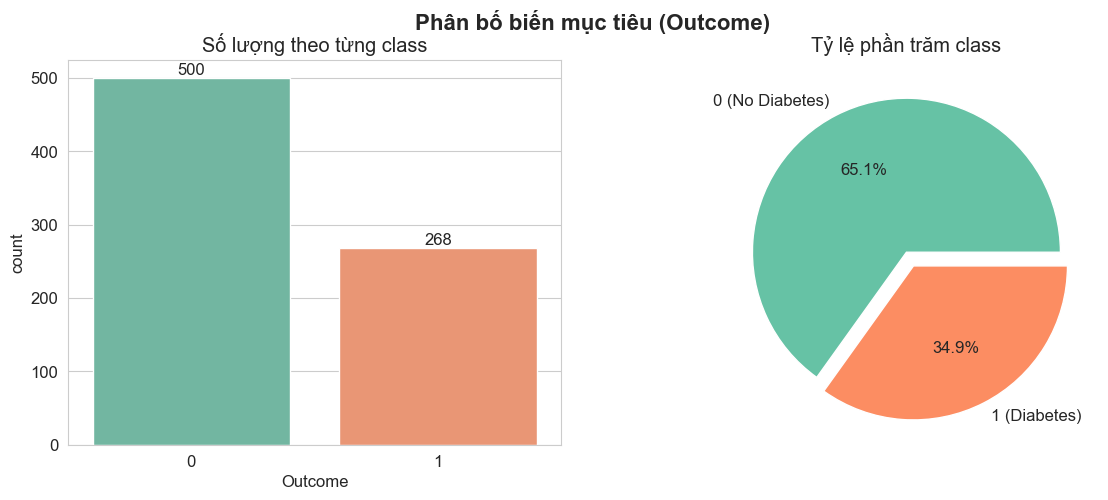

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x="Outcome", data=df, ax=axes[0], palette="Set2")
for p in axes[0].patches:
    axes[0].annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width()/2., p.get_height()), ha="center", va="bottom")
axes[0].set_title("Số lượng theo từng class")

axes[1].pie(df["Outcome"].value_counts(), labels=["0 (No Diabetes)", "1 (Diabetes)"], autopct="%1.1f%%", colors=sns.color_palette("Set2"), explode=[0, 0.1])
axes[1].set_title("Tỷ lệ phần trăm class")
plt.suptitle("Phân bố biến mục tiêu (Outcome)", fontsize=16, fontweight="bold")
plt.show()

**Nhận xét:** Dữ liệu bị mất cân bằng (imbalanced) với tỷ lệ 65% (0) và 35% (1). Chúng ta sẽ cần sử dụng SMOTE hoặc class_weight khi training để giải quyết.

## Section 5: Phân bố từng biến (Histogram + KDE)
Xem xét phân bố của các biến đầu vào để đánh giá độ lệch (skewness).

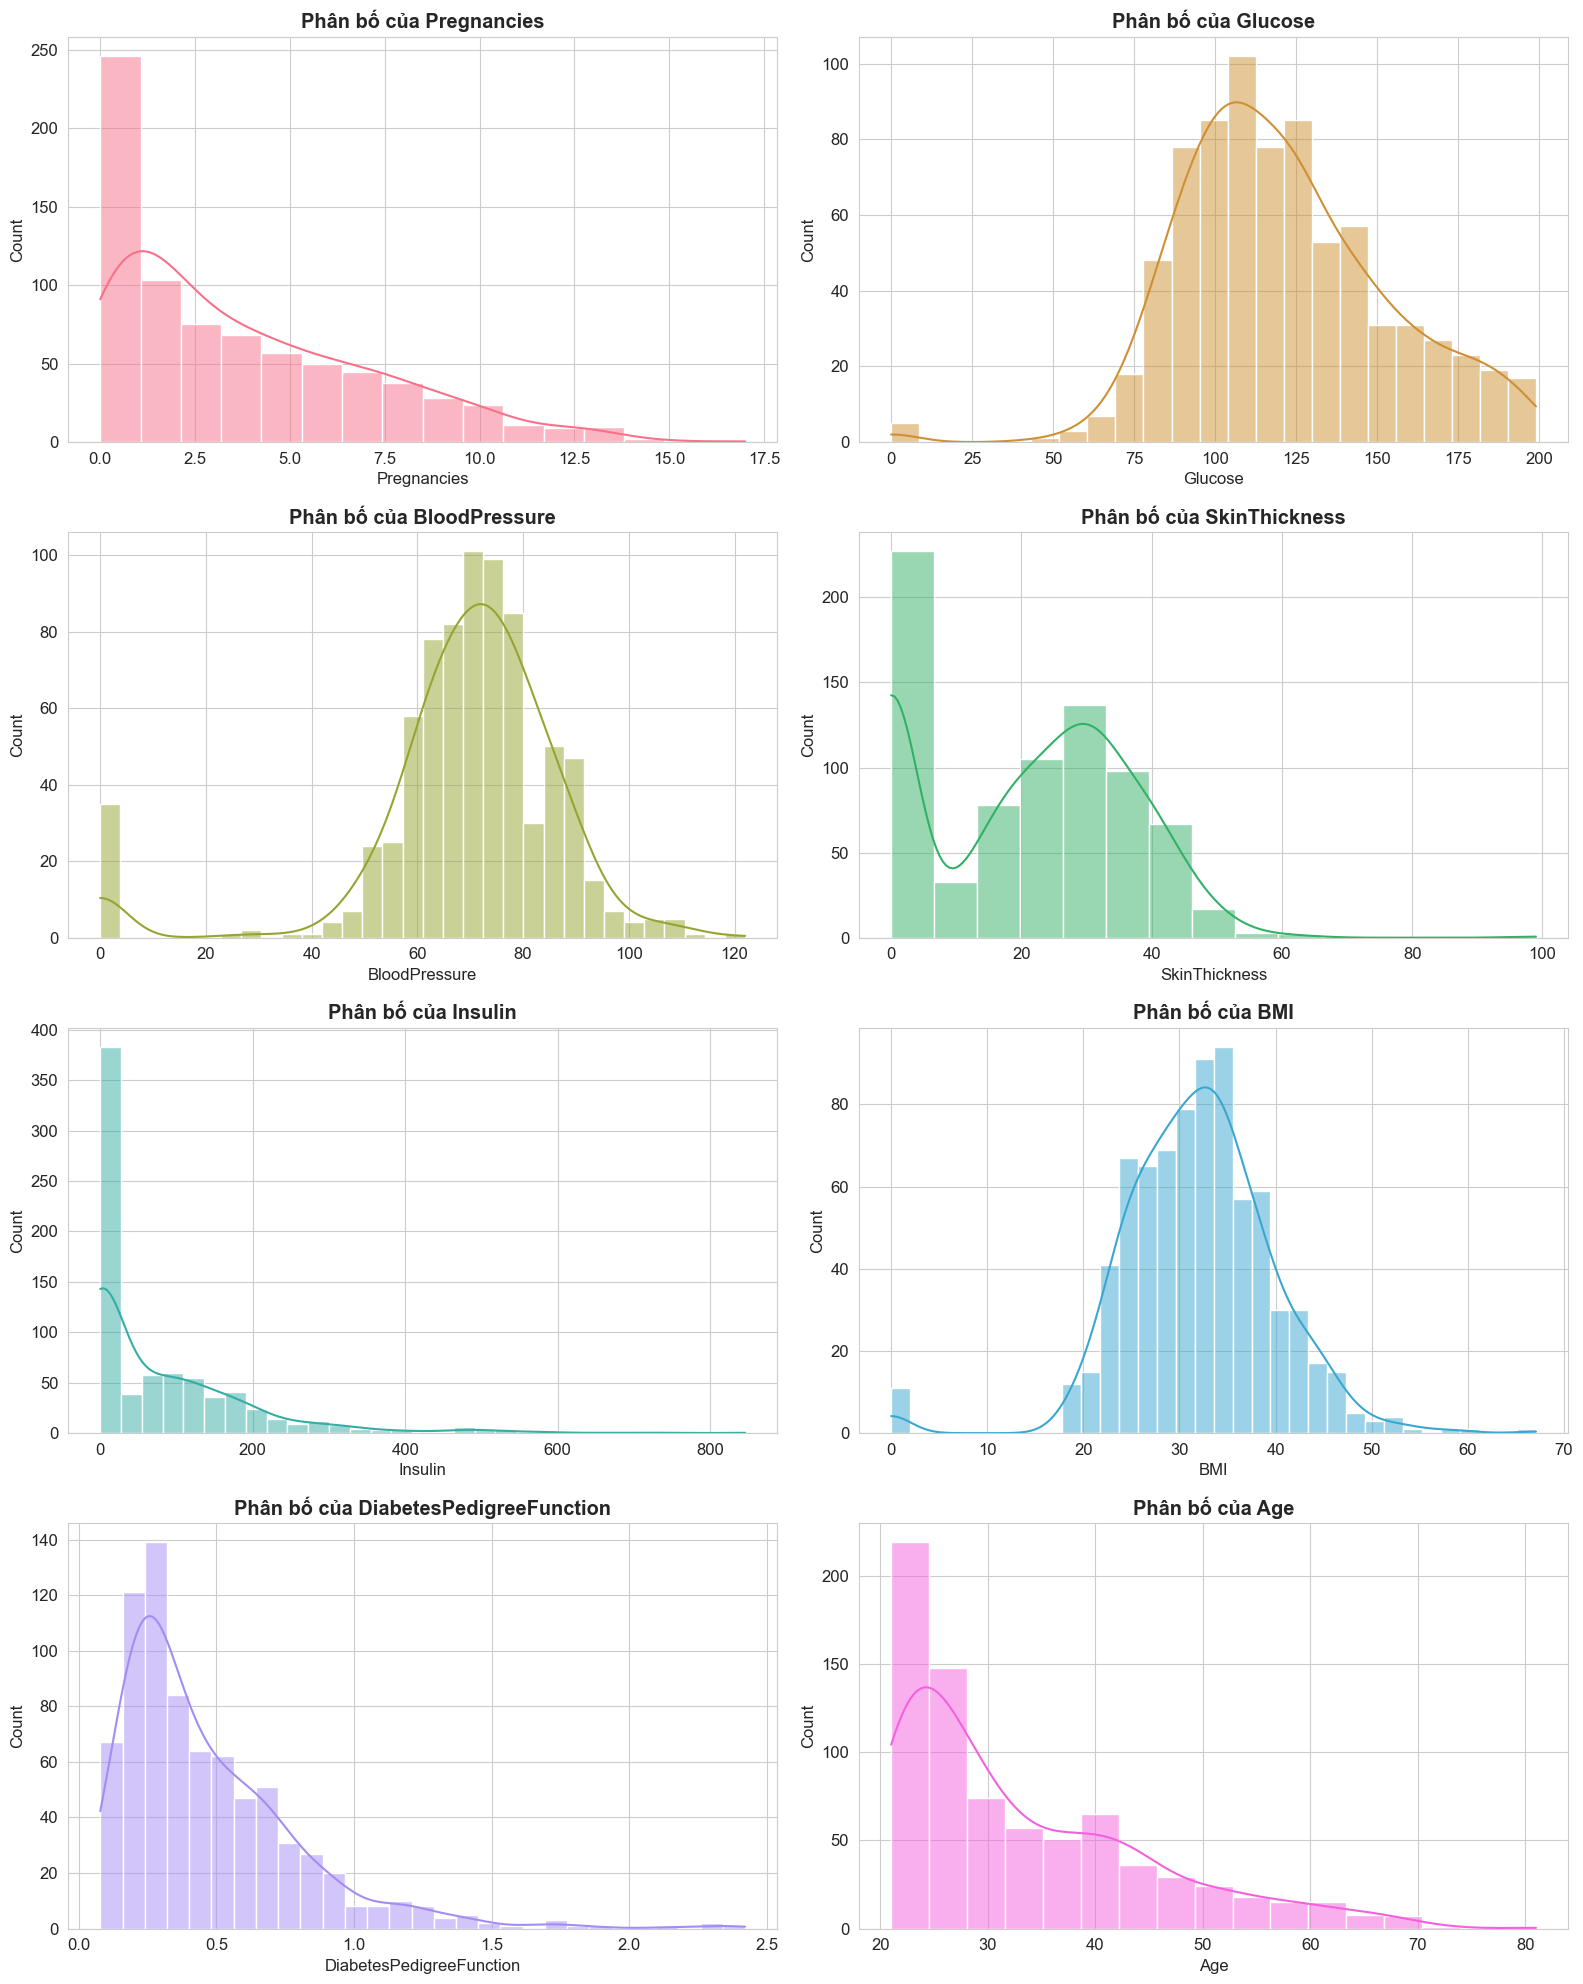

In [17]:
features = df.columns[:-1]
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
colors = sns.color_palette("husl", 8)

for i, col in enumerate(features):
    sns.histplot(df[col], kde=True, ax=axes[i], color=colors[i])
    axes[i].set_title(f"Phân bố của {col}", fontweight="bold")
    
plt.tight_layout()
plt.show()

**Nhận xét:**
- `Insulin`, `DiabetesPedigreeFunction`, `Age`, `Pregnancies` bị lệch phải (right-skewed) rất mạnh.
- Các cột như `Glucose`, `BloodPressure`, `BMI` trông có vẻ chuẩn (normal distribution) hơn nếu bỏ qua cục giá trị 0 ở đầu (do thiếu dữ liệu).

## Section 6: Boxplot phát hiện Outlier
Sử dụng Boxplot và phương pháp IQR để kiểm tra giá trị ngoại lai.

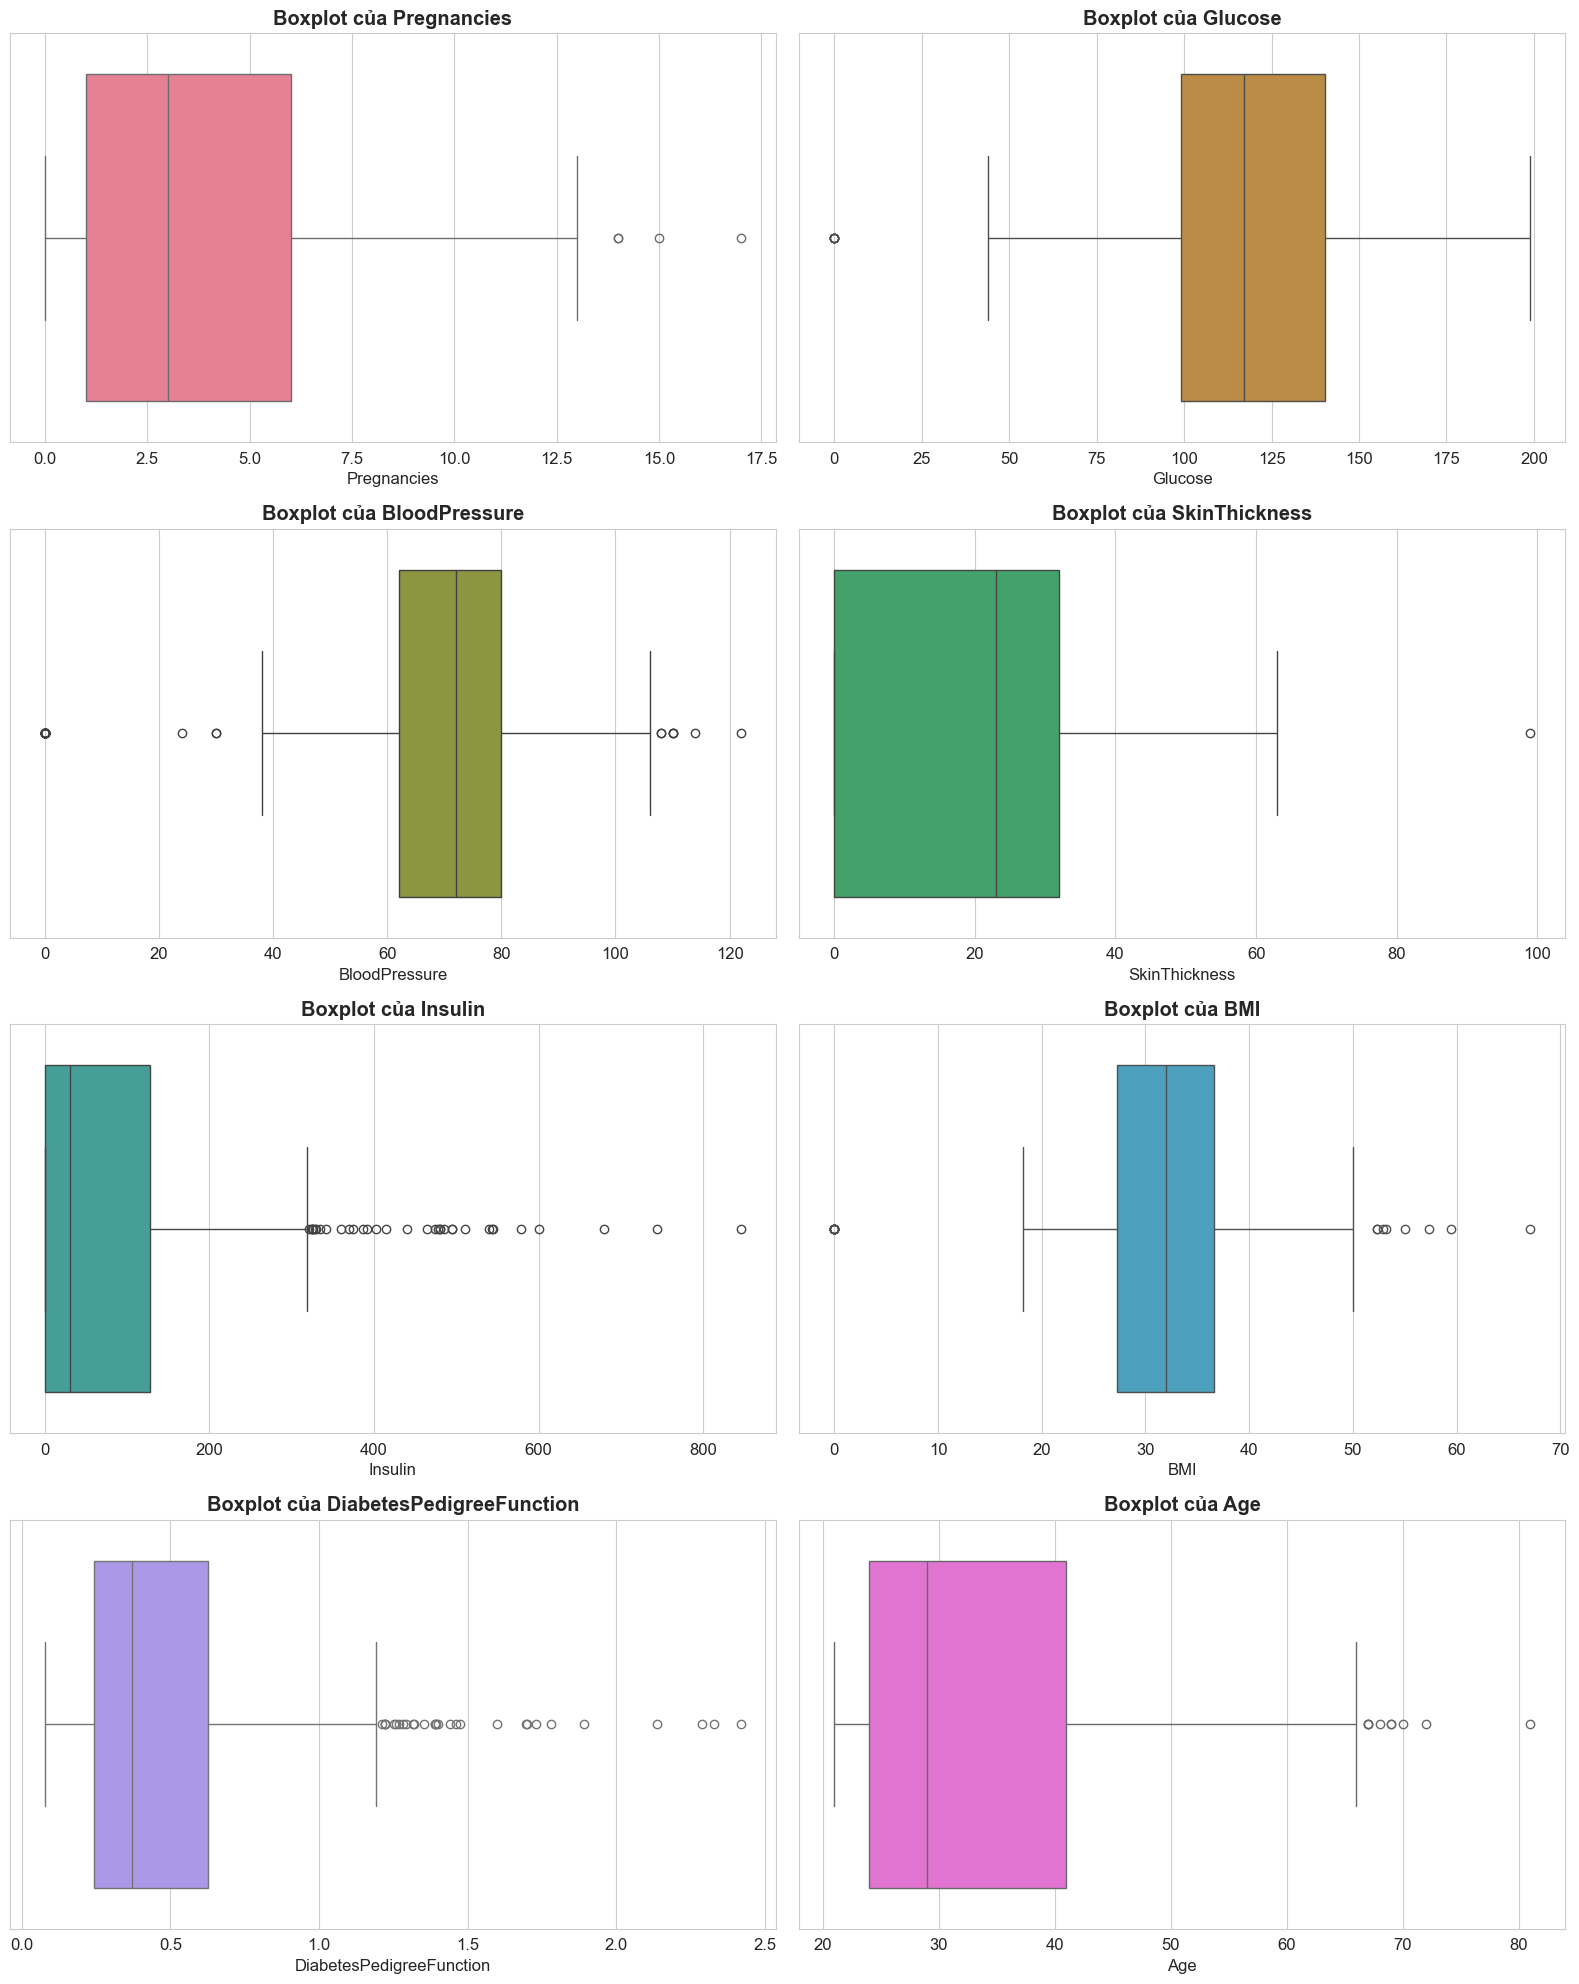

In [18]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"Boxplot của {col}", fontweight="bold")

plt.tight_layout()
plt.show()

In [19]:
outliers_dict = {}
for col in features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outliers_dict[col] = outliers

outliers_df = pd.DataFrame(list(outliers_dict.items()), columns=["Cột", "Số lượng Outliers"])
display(outliers_df)

,Cột,Số lượng Outliers
0,Pregnancies,4
1,Glucose,5
2,BloodPressure,45
3,SkinThickness,1
4,Insulin,34
5,BMI,19
6,DiabetesPedigreeFunction,29
7,Age,9


**Nhận xét:** Có khá nhiều outliers ở `Insulin`, `SkinThickness`, `DiabetesPedigreeFunction`, `BloodPressure`.
Tuy nhiên, với y tế, đôi khi giá trị cực đoan lại mang ý nghĩa cảnh báo bệnh lý. Chúng ta sẽ sử dụng model dựa trên Tree (Decision Tree, Random Forest) vốn robust với outliers, hoặc RobustScaler/Median Imputation ở bước sau.

## Section 7: Phân tích theo nhóm Outcome
So sánh sự khác biệt của các features giữa 2 nhóm có bệnh và không bệnh.

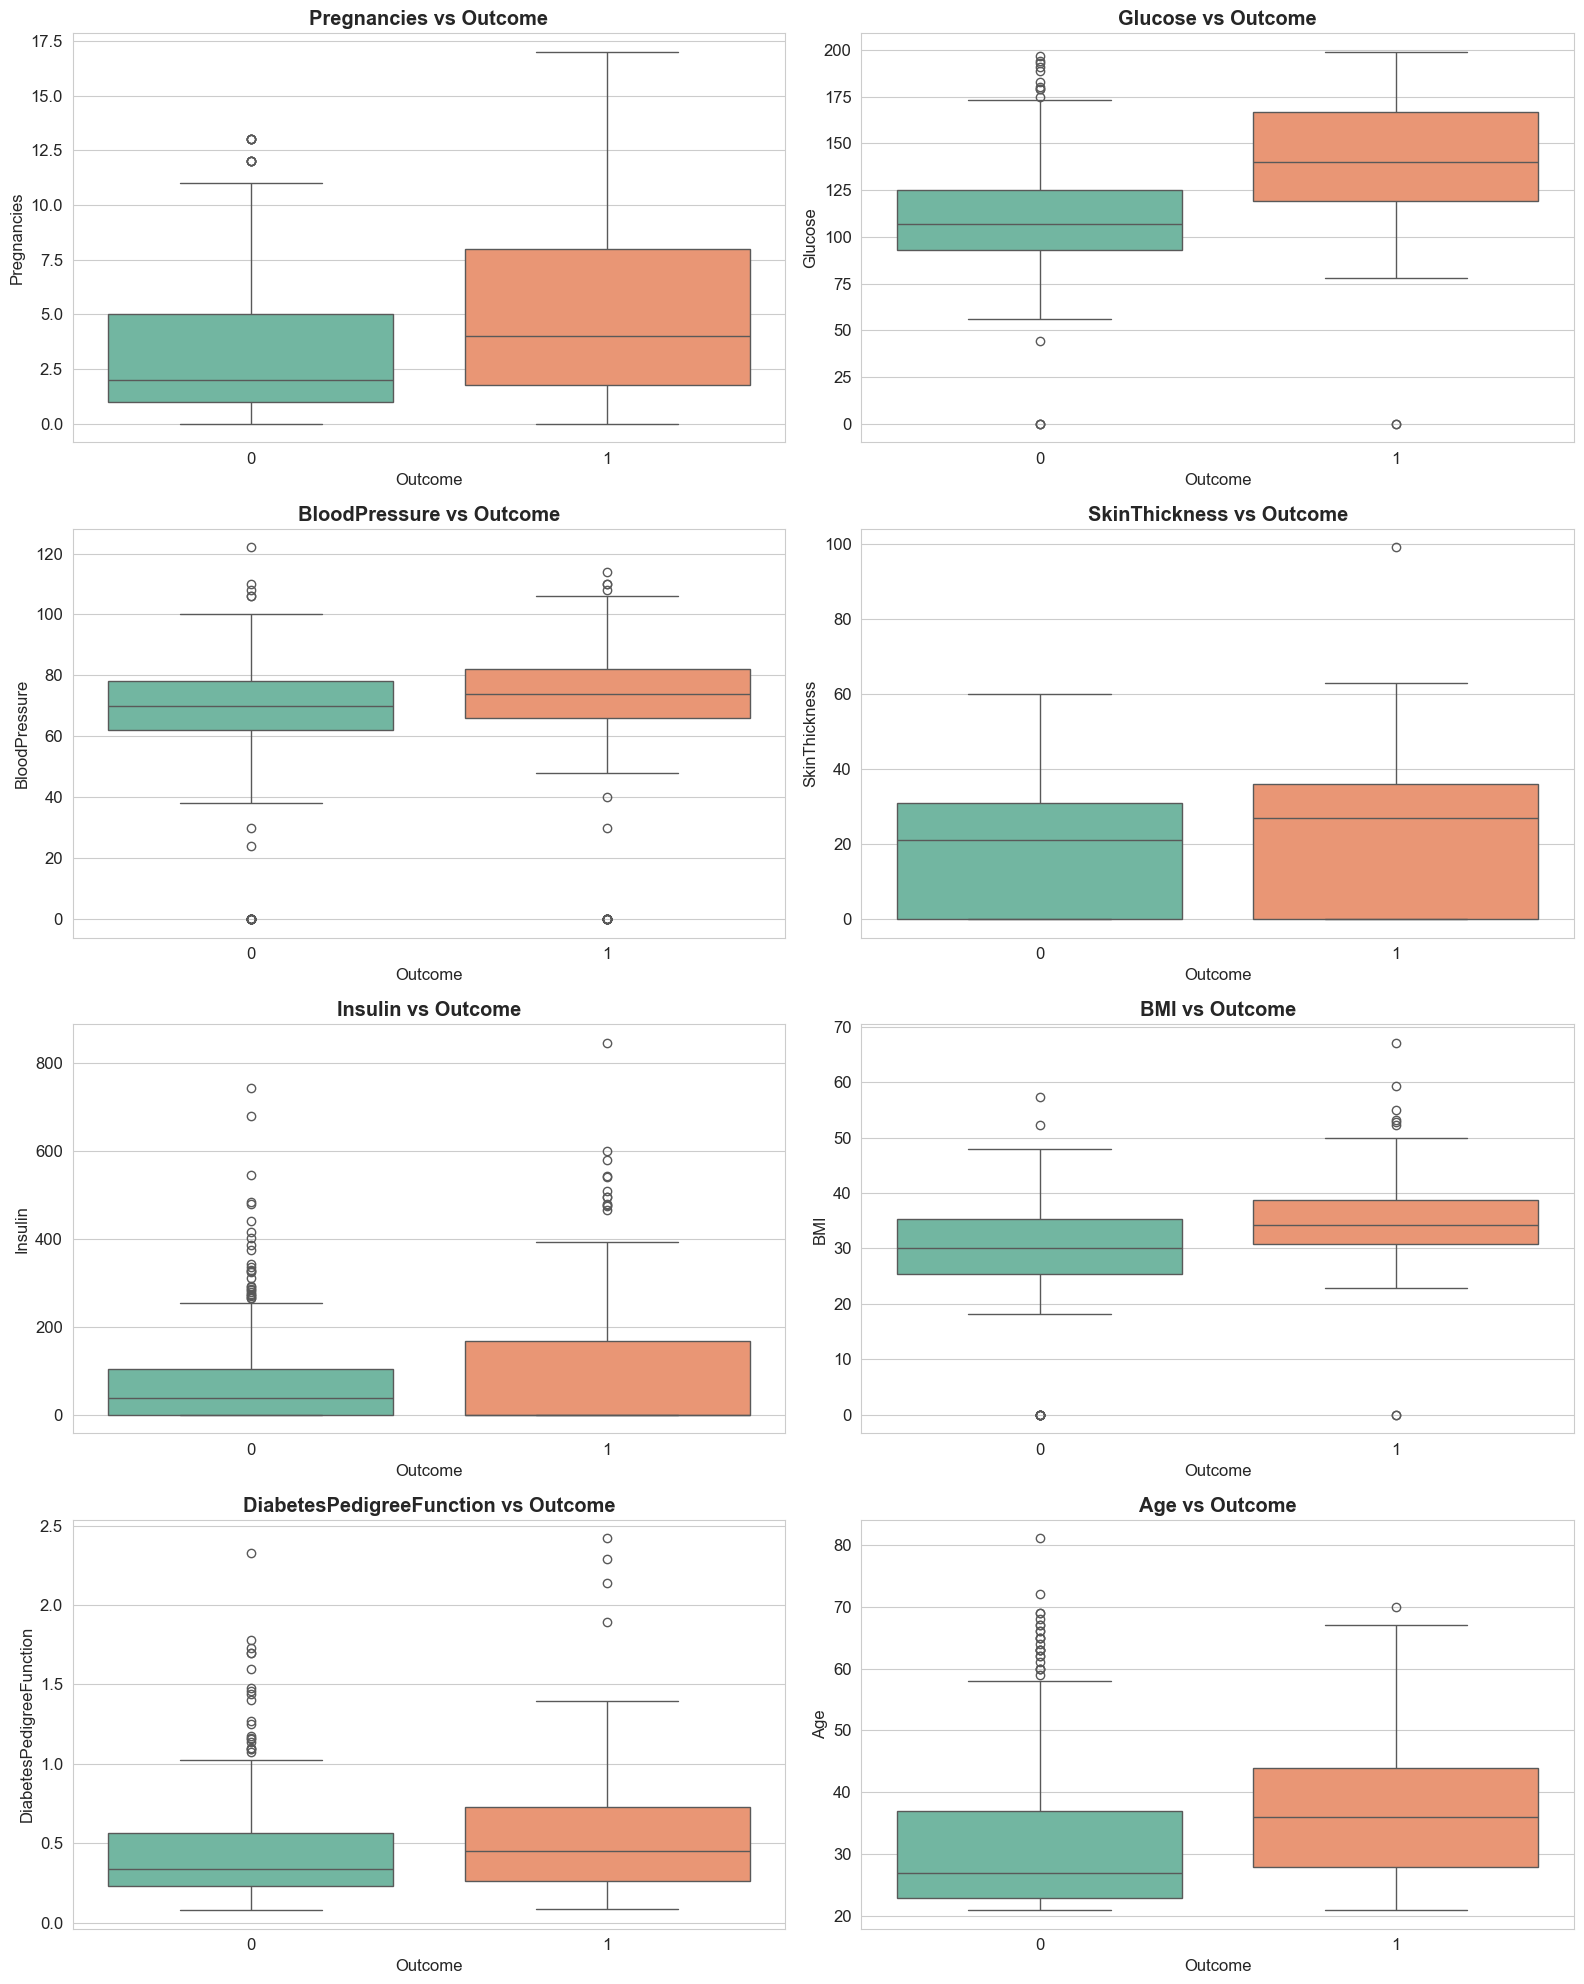

In [20]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(features):
    sns.boxplot(x="Outcome", y=col, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f"{col} vs Outcome", fontweight="bold")
plt.tight_layout()
plt.show()

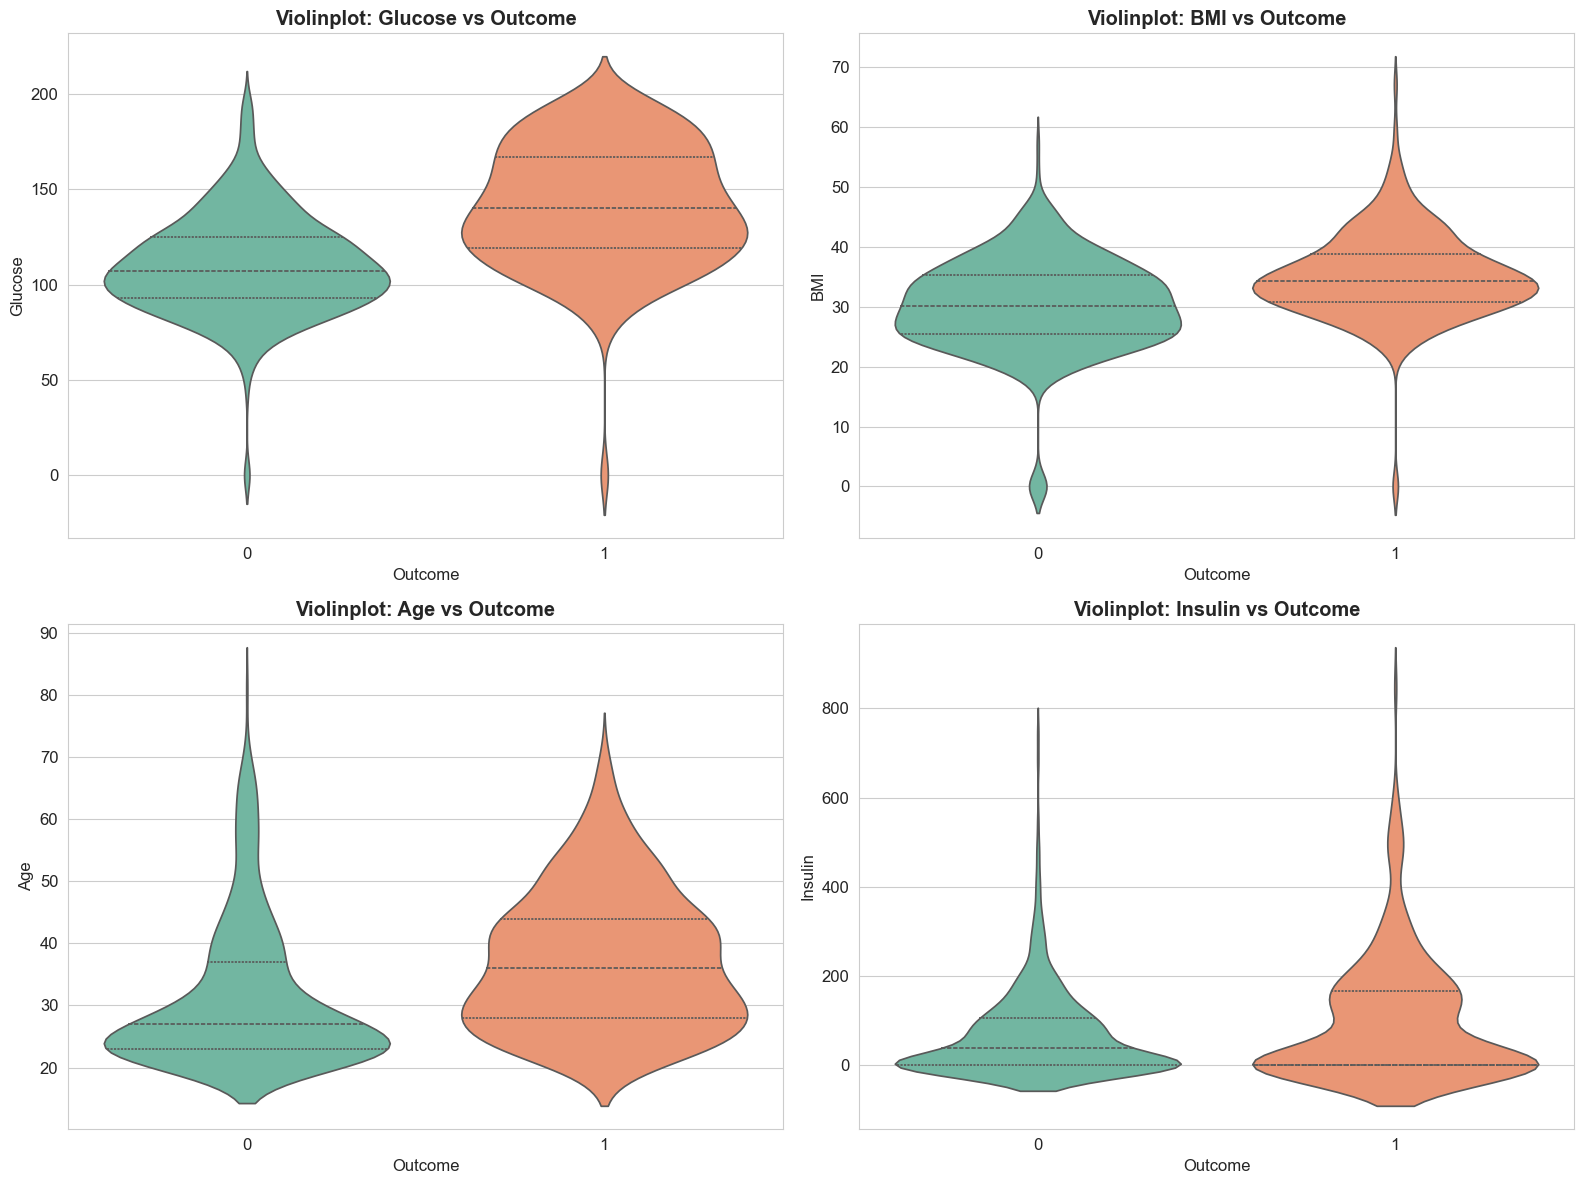

In [21]:
top_features = ["Glucose", "BMI", "Age", "Insulin"]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(top_features):
    sns.violinplot(x="Outcome", y=col, data=df, ax=axes[i], palette="Set2", inner="quartile")
    axes[i].set_title(f"Violinplot: {col} vs Outcome", fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
display(df.groupby("Outcome").mean().T)

Outcome,0,1
Pregnancies,3.298000,4.865672
Glucose,109.980000,141.257463
BloodPressure,68.184000,70.824627
SkinThickness,19.664000,22.164179
Insulin,68.792000,100.335821
BMI,30.304200,35.142537
DiabetesPedigreeFunction,0.429734,0.550500
Age,31.190000,37.067164


**Nhận xét:**
- Nhóm `Outcome=1` (tiểu đường) có giá trị trung bình của `Glucose` cao hơn hẳn so với nhóm 0 (141.25 vs 109.98).
- `BMI` và `Age` cũng cao hơn rõ rệt ở nhóm có bệnh.
- Đây là các đặc trưng quan trọng nhất để dự đoán.

## Section 8: Phân tích tương quan (Correlation)
Xem xét mức độ tương quan giữa các biến độc lập với nhau và với biến mục tiêu.

In [23]:
corr_matrix = df.corr()
display(round(corr_matrix, 2))

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.00,0.13,0.14,-0.08,-0.07,0.02,-0.03,0.54,0.22
Glucose,0.13,1.00,0.15,0.06,0.33,0.22,0.14,0.26,0.47
BloodPressure,0.14,0.15,1.00,0.21,0.09,0.28,0.04,0.24,0.07
SkinThickness,-0.08,0.06,0.21,1.00,0.44,0.39,0.18,-0.11,0.07
Insulin,-0.07,0.33,0.09,0.44,1.00,0.20,0.19,-0.04,0.13
BMI,0.02,0.22,0.28,0.39,0.20,1.00,0.14,0.04,0.29
DiabetesPedigreeFunction,-0.03,0.14,0.04,0.18,0.19,0.14,1.00,0.03,0.17
Age,0.54,0.26,0.24,-0.11,-0.04,0.04,0.03,1.00,0.24
Outcome,0.22,0.47,0.07,0.07,0.13,0.29,0.17,0.24,1.00


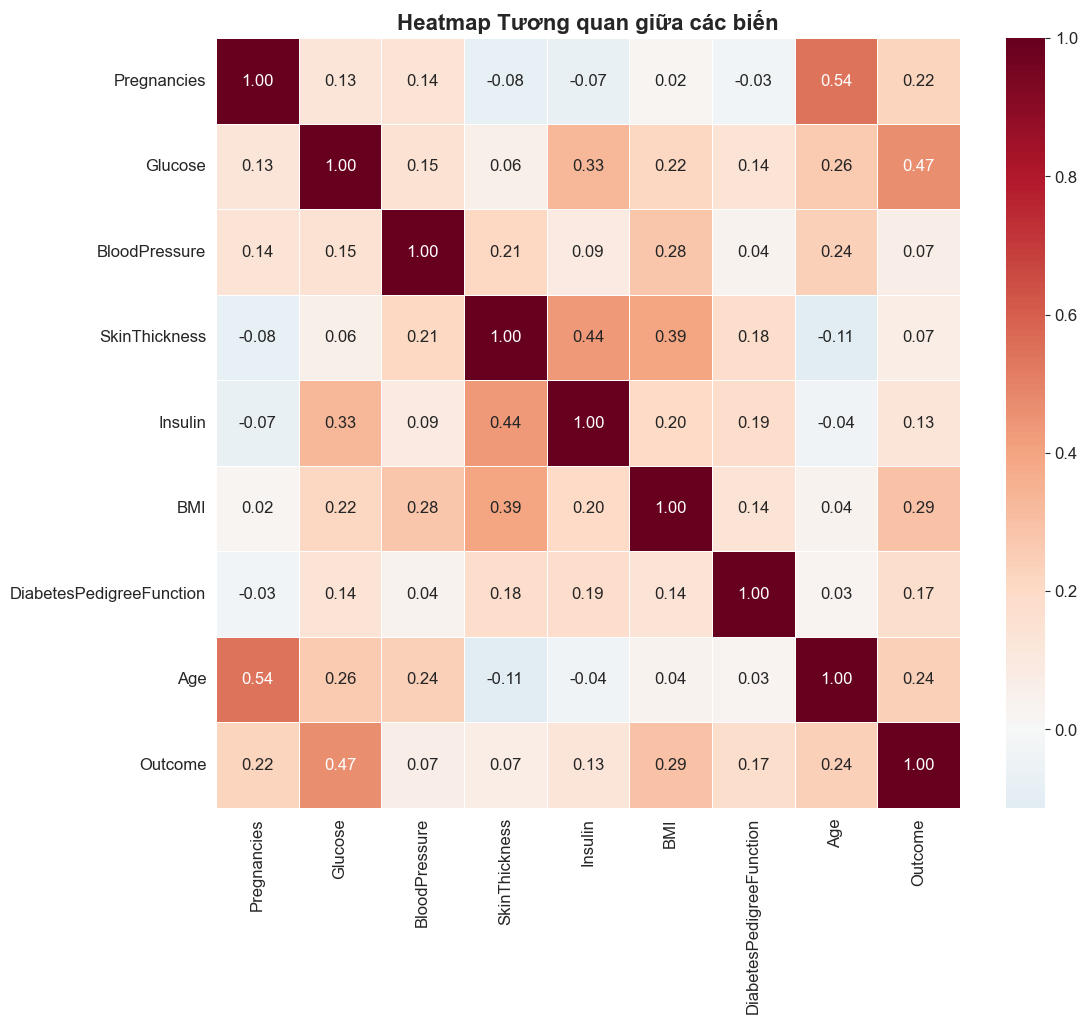

In [24]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".2f", linewidths=0.5)
plt.title("Heatmap Tương quan giữa các biến", fontsize=16, fontweight="bold")
plt.show()

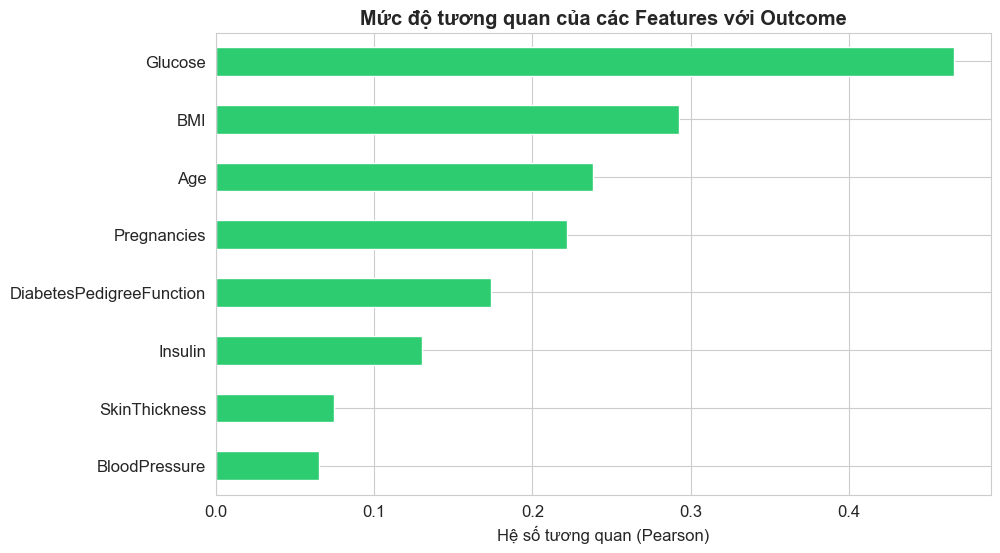

In [25]:
target_corr = corr_matrix["Outcome"].drop("Outcome").sort_values()
plt.figure(figsize=(10, 6))
colors = ["#e74c3c" if c < 0 else "#2ecc71" for c in target_corr]
target_corr.plot(kind="barh", color=colors)
plt.title("Mức độ tương quan của các Features với Outcome", fontweight="bold")
plt.xlabel("Hệ số tương quan (Pearson)")
plt.show()

**Nhận xét:**
- `Glucose` có tương quan dương mạnh nhất với `Outcome` (0.47).
- Tiếp theo là `BMI` (0.29), `Age` (0.24) và `Pregnancies` (0.22).
- Không có feature nào có tương quan âm đáng kể với Outcome.
- Tương quan giữa các features với nhau không quá cao (cao nhất là Age và Pregnancies ~0.54) -> Ít nguy cơ đa cộng tuyến (multicollinearity).

## Section 9: Pairplot cho các features quan trọng

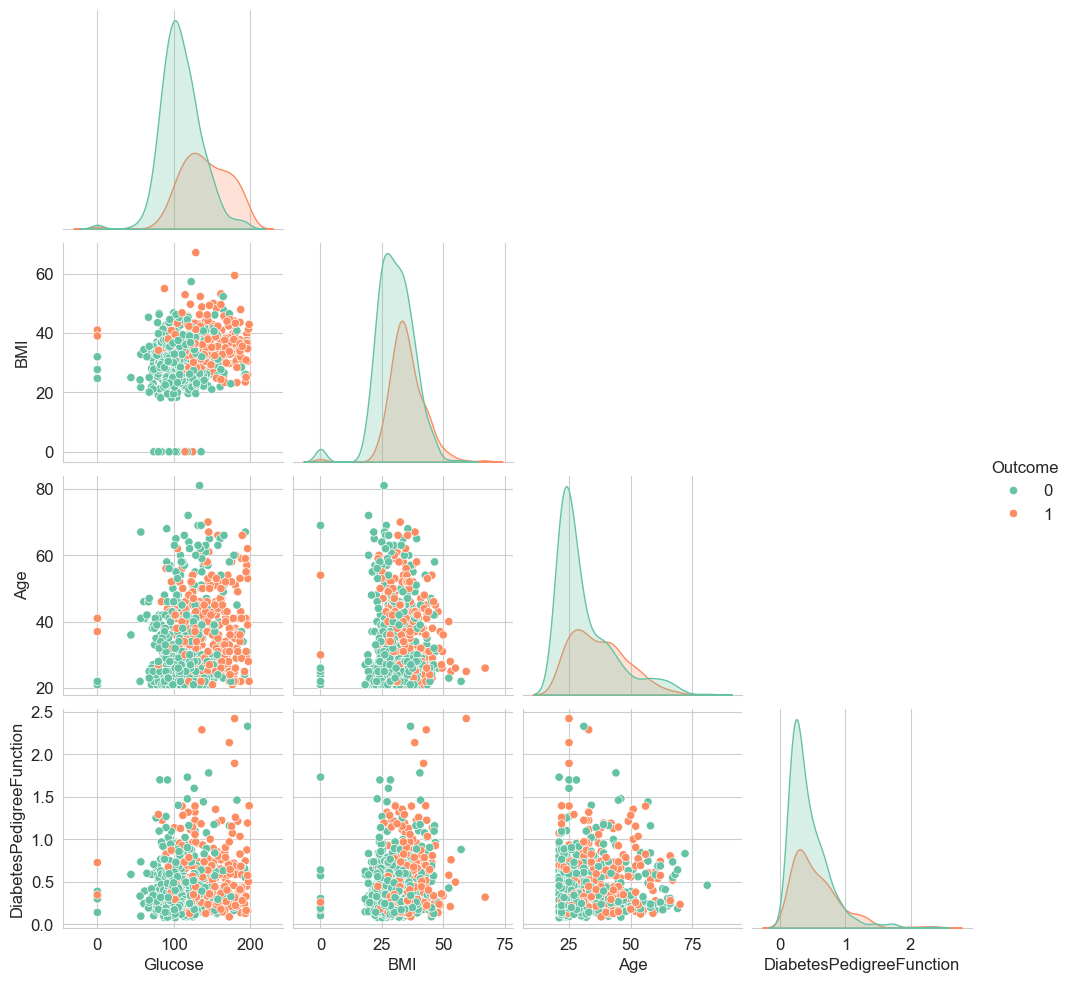

In [26]:
sns.pairplot(df[["Glucose", "BMI", "Age", "DiabetesPedigreeFunction", "Outcome"]], hue="Outcome", palette="Set2", corner=True)
plt.show()

## Section 10: Feature Selection - Chọn đặc trưng
Dựa trên phân tích EDA, chúng ta sẽ xem xét nên giữ lại các features nào.

Nhìn vào biểu đồ tương quan, tất cả các features đều có đóng góp (correlation > 0) vào việc dự báo biến mục tiêu. 

Vì số lượng đặc trưng khá ít (8 đặc trưng), việc loại bỏ (drop) feature có thể làm mất thông tin hữu ích cho các mô hình phi tuyến tính như Random Forest.

**Kết luận:** Chúng ta quyết định giữ lại **TẤT CẢ features** (full features). Mặc dù một số cột như SkinThickness có tương quan thấp hơn, nhưng thực tế với mô hình Tree-based, nó vẫn có thể mang giá trị khi kết hợp với các features khác.

## Section 11: Lựa chọn Models
Dựa trên đặc điểm bài toán (phân loại nhị phân) và dữ liệu, chúng ta sẽ chọn 3 models để huấn luyện và so sánh:

| Model | Đặc điểm | Lý do chọn |
|-------|----------|------------|
| Logistic Regression | Linear, nhanh, dễ giải thích | Dùng làm Baseline cho bài toán phân loại. |
| Decision Tree | Non-linear, dễ giải thích | Xử lý tốt dữ liệu không cần chuẩn hóa, trực quan. |
| Random Forest | Ensemble, mạnh mẽ | Khắc phục nhược điểm dễ overfitting của DT, hiệu suất thường rất tốt. |

## Section 12: Kết luận EDA

1. **Dataset:** 768 mẫu, 8 features, 1 target (Outcome).
2. **Dữ liệu BẨN:** Có rất nhiều giá trị 0 phi logic ở `Insulin` (48.7%), `SkinThickness` (29.6%), `BloodPressure`, `BMI` và `Glucose`. Cần tiền xử lý (Imputation).
3. **Mất cân bằng nhẹ:** 65% mẫu Không bệnh, 35% Có bệnh.
4. **Outliers:** Có xuất hiện ngoại lai ở nhiều biến, nhưng đây có thể là dấu hiệu bệnh lý, không nên drop bừa bãi.
5. **Features quan trọng:** `Glucose`, `BMI`, `Age` phân biệt tốt nhất hai nhóm.
6. **Hành động tiếp theo (Tiền xử lý):** Xử lý giá trị 0 thành NaN rồi dùng Median Imputer, Chuẩn hóa (Scaler), Cân bằng dữ liệu (SMOTE/class_weight).
7. **Modeling:** Giữ full 8 features và train 3 models: Logistic Regression, Decision Tree, Random Forest.